### **Applied Data Science with Python: Incremental Capstone**

#  Task 1: Import and Clean Data



In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('FloridaBikeRentals.csv')
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,01-12-2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01-12-2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01-12-2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01-12-2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01-12-2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [175]:
df.describe()

,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [176]:
df.shape

(8760, 14)

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   object 
 1   Rented Bike Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew point temperature  8760 non-null   float64
 8   Solar Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   object 
 12  Holiday                8760 non-null   object 
 13  Functioning Day        8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.3+ 

In [178]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
       'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation',
       'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning Day'],
      dtype='object')

In [179]:
df.dtypes

,0
Date,object
Rented Bike Count,int64
Hour,int64
Temperature,float64
Humidity,int64
Wind speed,float64
Visibility,int64
Dew point temperature,float64
Solar Radiation,float64
Rainfall,float64


In [180]:
df.duplicated().sum()

np.int64(0)

In [181]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature,0
Humidity,0
Wind speed,0
Visibility,0
Dew point temperature,0
Solar Radiation,0
Rainfall,0


##Data types Observations
- We notice that the dataset has many different columns filled with data that utilizes more memory than needed for type of data in the set.
- We can make these ineficiencies more efficient by casting these values to to types that take less memory to work.

 - For the data set, it can be observed that the "Date" information is a object type
 - this can be converted to a datetime object instead to allow for proper analysis in regards to time

 - Then we can convert categorical columns like "Seasons" and "Holiday" to Category objects to reduce memory usage and allow for proper storage.

 - Then this also will continue for other columns by casting the data types to ones that are more efficient for the dataset we have and to allow for easier analysis, while still keeping the precision needed for the data.

In [182]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [183]:
df['Seasons'] = df['Seasons'].astype('category')
df['Holiday'] = df['Holiday'].astype('category')
df['Functioning Day'] = df['Functioning Day'].astype('category')

df['Temperature'] = df['Temperature'].astype('float')
df['Humidity'] = pd.to_numeric(df['Humidity'], downcast='integer')
df['Wind speed'] = df['Wind speed'].astype('float')
df['Hour'] = pd.to_numeric(df['Hour'], downcast='integer')
df['Rented Bike Count'] = pd.to_numeric(df['Rented Bike Count'], downcast='integer')


In [184]:
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [185]:
df[df['Rented Bike Count'] < 0].shape

(0, 14)

In [186]:
df.dtypes

,0
Date,datetime64[ns]
Rented Bike Count,int16
Hour,int8
Temperature,float64
Humidity,int8
Wind speed,float64
Visibility,int64
Dew point temperature,float64
Solar Radiation,float64
Rainfall,float64


In [187]:
df.memory_usage(deep=True)

,0
Index,132
Date,70080
Rented Bike Count,17520
Hour,8760
Temperature,70080
Humidity,8760
Wind speed,70080
Visibility,70080
Dew point temperature,70080
Solar Radiation,70080


In [188]:
df.to_json("bike_rental_cleaned.json", orient="records", lines=False)

dfCheck = pd.read_json("bike_rental_cleaned.json")
dfCheck.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


# Observations for part 1

- The data set containing Florida Bike Rentals was successfully imported and cleaned
  - The data set was complete with no missing values or duplicate data
  - The data types of the columns were another story as some were stored in highly inneficient data types that could be casted to more efficient data types that would in the future allow for further analysis and processing.

- The Data is now, after being cleaned, exported to a JSON file for future use.

## ----------------------------------------------------------------------------------------------

## Task 2: Data Processing and Statistical Analysis

In [189]:
# Perform Transformations:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Visibility_scaled'] = scaler.fit_transform(df[['Visibility']])
df['Temperature_By_10'] = df['Temperature'] * 10



In [190]:
df[['Temperature', 'Temperature_By_10',  'Humidity', 'Rented Bike Count', 'Visibility', 'Visibility_scaled']].describe()

,Temperature,Temperature_By_10,Humidity,Rented Bike Count,Visibility,Visibility_scaled
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,12.882922,128.829224,58.226256,704.602055,1436.825799,0.714559
std,11.944825,119.448252,20.362413,644.997468,608.298712,0.308312
min,-17.800000,-178.000000,0.000000,0.000000,27.000000,0.000000
25%,3.500000,35.000000,42.000000,191.000000,940.000000,0.462747
50%,13.700000,137.000000,57.000000,504.500000,1698.000000,0.846934
75%,22.500000,225.000000,74.000000,1065.250000,2000.000000,1.000000
max,39.400000,394.000000,98.000000,3556.000000,2000.000000,1.000000


In [191]:
df.describe()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Visibility_scaled,Temperature_By_10
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2018-05-31 23:59:59.999999744,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,0.714559,128.829224
min,2017-12-01 00:00:00,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000,-178.000000
25%,2018-03-02 00:00:00,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,0.462747,35.000000
50%,2018-06-01 00:00:00,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,0.846934,137.000000
75%,2018-08-31 00:00:00,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,1.000000,225.000000
max,2018-11-30 00:00:00,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000,1.000000,394.000000
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,0.308312,119.448252


## Statistical Analysis

- The categorical collumns like Seasons, Holiday, and Functioning Day are not used in Statistical analysis, as can be seen with the use of the describe function since they are not in the output at all.
- The Date column as well is not suitable for direct statistical analysis but is already converted to proper datetime object.

In [192]:
#Exporting Analyzed Data to CSV

df.to_csv("bike_rental_processed.csv", index=False)

##Statistical Observations and Insights
- There are many things to take note of for Statistical Analysis of the data, such as with temperature, rented bikes, Visibility
- Temperature: We can see the value's range from -17.8°C to 39.4°C, with an average of 12.9°C
- The Temperature_by_10 column also shows a proportional transformation of the temperature data.
-Visibility was scaled using MinMax Scalling to help compare it better to other features using 0-1 scalling.
- Categorical Columns were found to not be compatible with the numerical statistical analysis.

- Then we put this dataframe into a new CSV file as well.

## ----------------------------------------------------------------------------------------------

## Task 3: Data Analysis with Pandas

##1. Identify categorical and numerical variables

- Categorical: Seasons, Holiday, Functioning Day are considered labels or groups, not numbers.

- Numerical: Columns like Rented Bike Count, Temperature, Visibility, Humidity, Wind Speed, and others are considered numerical categories. These can be statistically analysed as we saw earlier because they are discrete numbers

In [193]:
df.groupby('Seasons')['Rented Bike Count'].mean()

/tmp/ipython-input-3467896004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Seasons')['Rented Bike Count'].mean()


,Rented Bike Count
Seasons,
Autumn,819.597985
Spring,730.031250
Summer,1034.073370
Winter,225.541204


In [194]:
df.groupby('Holiday')['Rented Bike Count'].mean()

/tmp/ipython-input-2594882961.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Holiday')['Rented Bike Count'].mean()


,Rented Bike Count
Holiday,
Holiday,499.756944
No Holiday,715.228026


In [195]:
df.groupby('Functioning Day')['Rented Bike Count'].mean()

/tmp/ipython-input-2291395334.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Functioning Day')['Rented Bike Count'].mean()


,Rented Bike Count
Functioning Day,
No,0.000000
Yes,729.156999


In [196]:
df.pivot_table(index='Hour', values=["Temperature", "Rented Bike Count"], aggfunc='mean')

,Rented Bike Count,Temperature
Hour,,
0,541.460274,11.286301
1,426.183562,10.923288
2,301.630137,10.591507
3,203.331507,10.293699
4,132.591781,10.026301
5,139.082192,9.768767
6,287.564384,9.560548
7,606.005479,9.581096
8,1015.701370,10.176986


In [197]:
df.pivot_table(index='Seasons', values="Rented Bike Count", aggfunc='mean')

/tmp/ipython-input-3012385304.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='Seasons', values="Rented Bike Count", aggfunc='mean')


,Rented Bike Count
Seasons,
Autumn,819.597985
Spring,730.031250
Summer,1034.073370
Winter,225.541204


In [198]:
encoded_df = pd.get_dummies(df, columns=['Seasons', 'Holiday', 'Functioning Day'], dtype=int)

encoded_df.to_csv("Rental_Bike_Data_Dummy.csv", index=False)

encoded_df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,...,Visibility_scaled,Temperature_By_10,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,1.0,-52.0,0,0,0,1,0,1,0,1
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,1.0,-55.0,0,0,0,1,0,1,0,1
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,1.0,-60.0,0,0,0,1,0,1,0,1
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,1.0,-62.0,0,0,0,1,0,1,0,1
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,1.0,-60.0,0,0,0,1,0,1,0,1


## ----------------------------------------------------------------------------------------------

## Task 4: Data Visualization

/tmp/ipython-input-2447815011.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_avg = (df.groupby('Seasons')['Rented Bike Count']


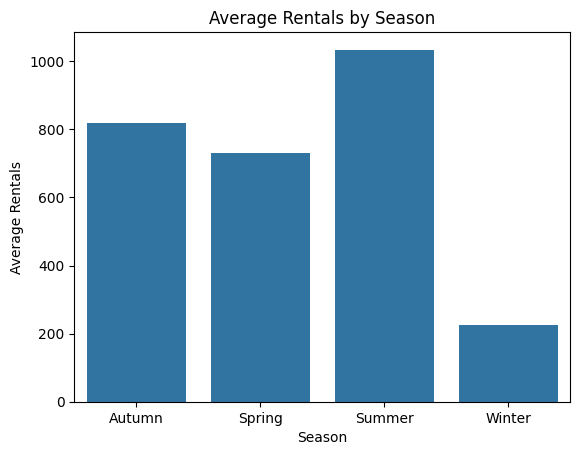

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns

season_avg = (df.groupby('Seasons')['Rented Bike Count']
              .mean()
              .sort_values(ascending=True))

sns.barplot(x=season_avg.index, y=season_avg.values)
plt.title('Average Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Average Rentals')
plt.savefig("RentalsBySeason.png", dpi=150)
plt.show()

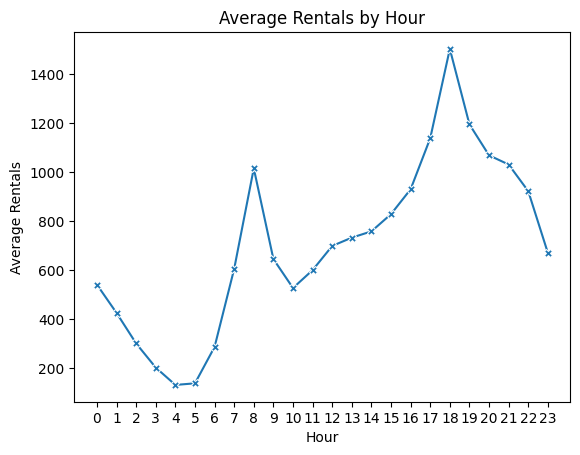

In [200]:
hour_line = df.groupby('Hour')['Rented Bike Count'].mean()

sns.lineplot(x=hour_line.index, y=hour_line.values, marker="X")
plt.title('Average Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.xticks(range(0, 24))
plt.savefig("RentalsByHour.png", dpi=150)
plt.show()

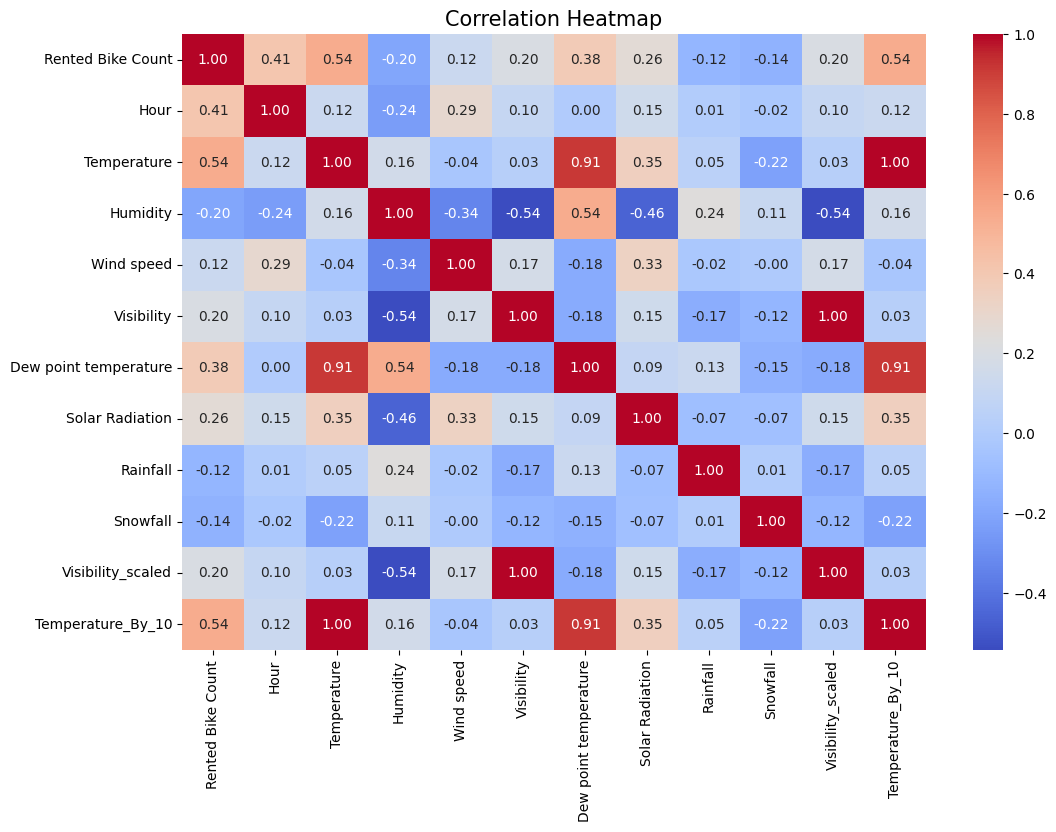

<Figure size 1200x800 with 0 Axes>

In [201]:
number_col = df.select_dtypes(include=['number'])
corr = number_col.corr()

plt.figure(figsize=(12, 8))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
ax.set_title('Correlation Heatmap', fontsize=15)
plt.figure(figsize=(12, 8))
plt.savefig("CorrelationHeatmap.png", dpi=150)
plt.show()

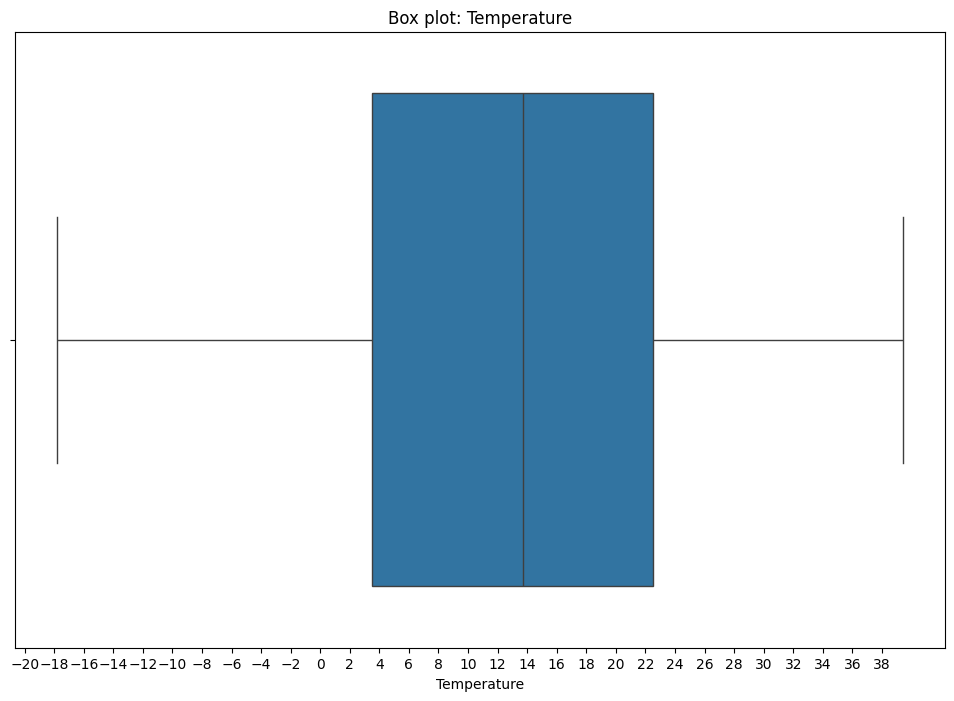

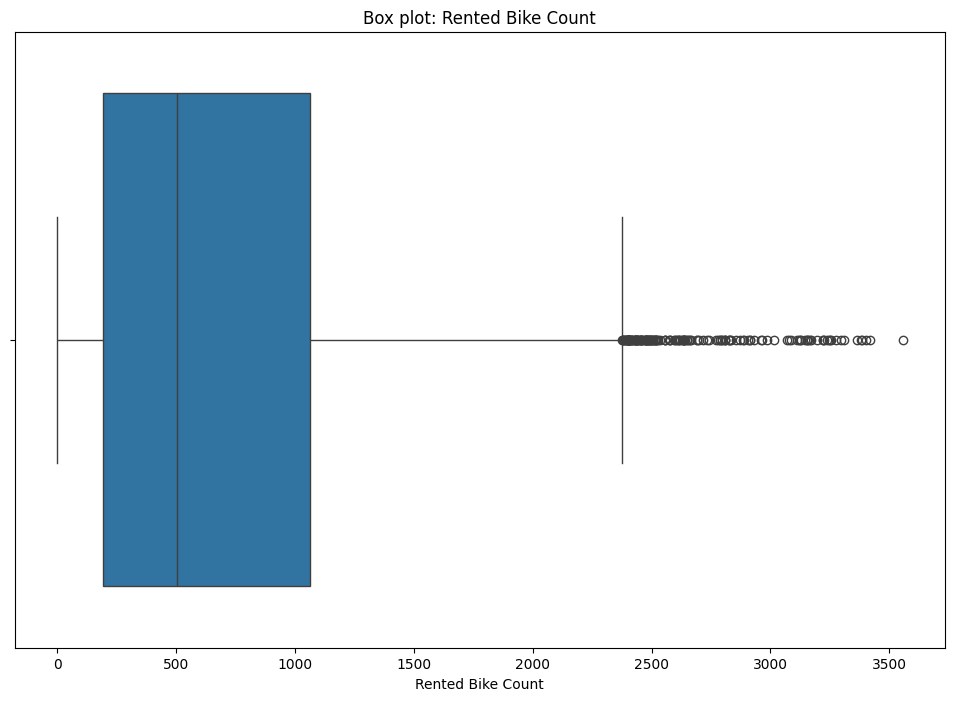

In [202]:
# Box Plot
plt.figure(figsize=(12, 8))
sns.boxplot(x=df['Temperature'])
plt.title('Box plot: Temperature')
plt.xticks(range(-20, 40, 2))
plt.savefig("BoxPlotTemp.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(x=df['Rented Bike Count'])
plt.title('Box plot: Rented Bike Count')
plt.savefig("BoxPlotBikeCount.png", dpi=150)
plt.show()

## Bar Chart Observations

- It can be seen with the bar plot that after figuring out the mean rentals during each season of the year, that rentals are the highest during the summer while lowest in the winter. This also clearly shows that demand is way down in winter

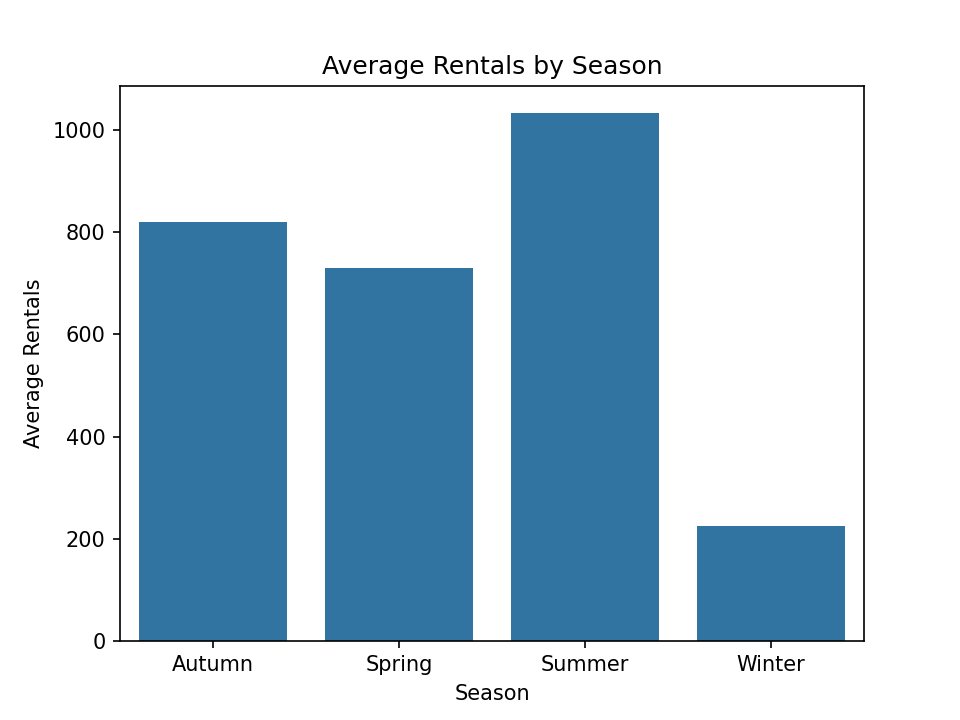

## Line Chart Observations

- The line plot for avg Rentals by the Hour shows a cycle with two peak rental times, one being in the morning around 8-9 AM, and the second peak being in the evening around 5-7 PM.
- These peaks showcase a clear connection between preferred times for renting bikes which may relate to usual commuting patterns.

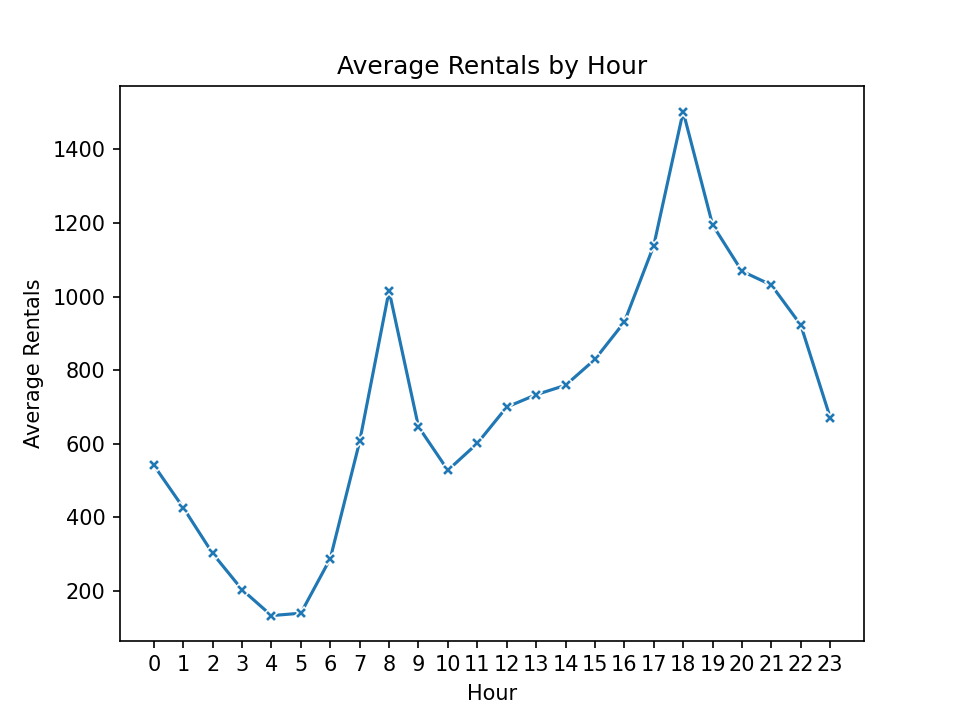

## Heatmap Observations

- One of the main observations that can be derived from the heatmap is how there is a strong positive correlation between Temperature and Rented Bike Count of about 0.54.
- This shows a positive correlation as the higher temperature, the more bikes are rented/
- There is also a positve correlation between the Hours and Bikes rented, which reinforces the data from the line plot as well.
- Many of the other columns of the chart show rather poor or negative correlations in relation to one another, while certain temperature/weather measurements are correlating with one another.



## Box Plot Observations

- Temperature Box Plot
  - Looking at the box plot, most of the temp values are between 4°C and 23°C, with a median around 13 to 15°C.
  - This plot also has no extreme outliers in the data and is consistent

- Rented Bike Count Box Plot
  - The counts are much more spread out compared to temperature plot.
  - The plot shows a median of about 500 rentals across the data.
  - As can be seen, there are a big amount of outliers in the data that go past the "whiskers" of the plot. These spikes represent times where the rental amount was just so much bigger than usual that it creates an outlier.
  - Overall the graph shows a steady stream of rentals on average, while showing there are cases of huge surges in rentals.